# BTVN Buổi 11 — Ensemble Learning với Spaceship Titanic

**Sinh viên thực hiện:** Nguyễn Huỳnh Nam Quốc  
**MSSV:** 2453089  
**GitHub:** namquoc2108-bot  

## Mục tiêu

- Khám phá dữ liệu Spaceship Titanic.
- Xử lý missing values và tạo thêm đặc trưng.
- So sánh Bagging, Random Forest, Extra Trees, Gradient Boosting và Stacking.
- Tạo thêm probability blending và group-aware blending.
- Huấn luyện lại trên toàn bộ tập train.
- Xuất các file submission để nộp Kaggle.

> Notebook cần ba file `train.csv`, `test.csv`, `sample_submission.csv` trong thư mục `data/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
sns.set_context("notebook")

print("Import thư viện thành công.")

Import thư viện thành công.


## 1. Đọc dữ liệu

Cấu trúc thư mục khuyến nghị:

```text
week06/
└── Homework_11/
    ├── HW11_spaceship_titanic_2453089.ipynb
    └── data/
        ├── train.csv
        ├── test.csv
        └── sample_submission.csv
```

In [2]:
def find_data_dir():
    candidates = [
        Path("data"),
        Path("./data"),
        Path("week06/Homework_11/data"),
        Path("../data"),
    ]

    for candidate in candidates:
        required = [
            candidate / "train.csv",
            candidate / "test.csv",
            candidate / "sample_submission.csv",
        ]

        if all(path.exists() for path in required):
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy đủ train.csv, test.csv và sample_submission.csv. "
        "Hãy đặt ba file vào thư mục data/ cạnh notebook."
    )


DATA_DIR = find_data_dir()

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("DATA_DIR:", DATA_DIR.resolve())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

display(train_df.head())

DATA_DIR: C:\Users\Nam Quoc\OneDrive\Documents\BK HCM\Full_Semester\HK253\Khóa học Machine Learning & IoT Lab\mliot-pyml-2026-hw-main\mliot-pyml-2026-hw-main\mliot-pyml-2026-hw-fork\week06\Homework_11\data
Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Kiểm tra tổng quan dữ liệu

In [3]:
print("Thông tin train:")
train_df.info()

missing_table = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_percent": train_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

print("\nBảng missing values:")
display(missing_table)

print("Số dòng trùng lặp:", train_df.duplicated().sum())

print("\nPhân bố target:")
display(train_df["Transported"].value_counts())

print("\nTỷ lệ target:")
display(train_df["Transported"].value_counts(normalize=True))

Thông tin train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

Bảng missing values:


,missing_count,missing_percent
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
Spa,183,2.105142
FoodCourt,183,2.105142
Destination,182,2.093639


Số dòng trùng lặp: 0

Phân bố target:


Transported
True     4378
False    4315
Name: count, dtype: int64


Tỷ lệ target:


Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

### Nhận xét dữ liệu ban đầu

Dữ liệu gồm cả biến số và biến phân loại, đồng thời nhiều cột có missing values. Em xử lý missing values bằng pipeline để tránh xóa quá nhiều hành khách.

Biến mục tiêu `Transported` gần cân bằng, vì vậy Accuracy là metric phù hợp với cách chấm của Kaggle. Khi chia train/validation, em dùng `stratify=y` để giữ tỷ lệ hai lớp gần giống nhau.

`PassengerId` và `Cabin` chứa thông tin có cấu trúc. Em tách group, member, deck, cabin number và cabin side. Em cũng tạo các biến tổng chi tiêu để mô hình dễ học hành vi chung.

## 3. EDA

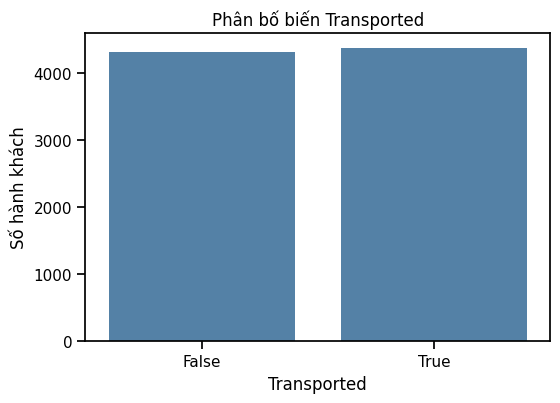

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train_df,
    x="Transported",
    color="steelblue"
)

plt.title("Phân bố biến Transported")
plt.xlabel("Transported")
plt.ylabel("Số hành khách")
plt.show()

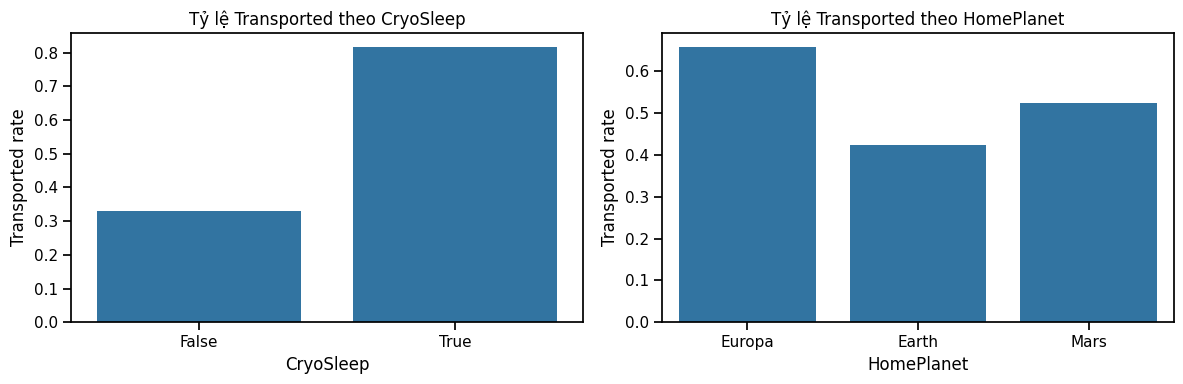

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

try:
    sns.barplot(
        data=train_df,
        x="CryoSleep",
        y="Transported",
        errorbar=None,
        ax=axes[0]
    )
    sns.barplot(
        data=train_df,
        x="HomePlanet",
        y="Transported",
        errorbar=None,
        ax=axes[1]
    )
except TypeError:
    sns.barplot(
        data=train_df,
        x="CryoSleep",
        y="Transported",
        ci=None,
        ax=axes[0]
    )
    sns.barplot(
        data=train_df,
        x="HomePlanet",
        y="Transported",
        ci=None,
        ax=axes[1]
    )

axes[0].set_title("Tỷ lệ Transported theo CryoSleep")
axes[0].set_xlabel("CryoSleep")
axes[0].set_ylabel("Transported rate")

axes[1].set_title("Tỷ lệ Transported theo HomePlanet")
axes[1].set_xlabel("HomePlanet")
axes[1].set_ylabel("Transported rate")

plt.tight_layout()
plt.show()

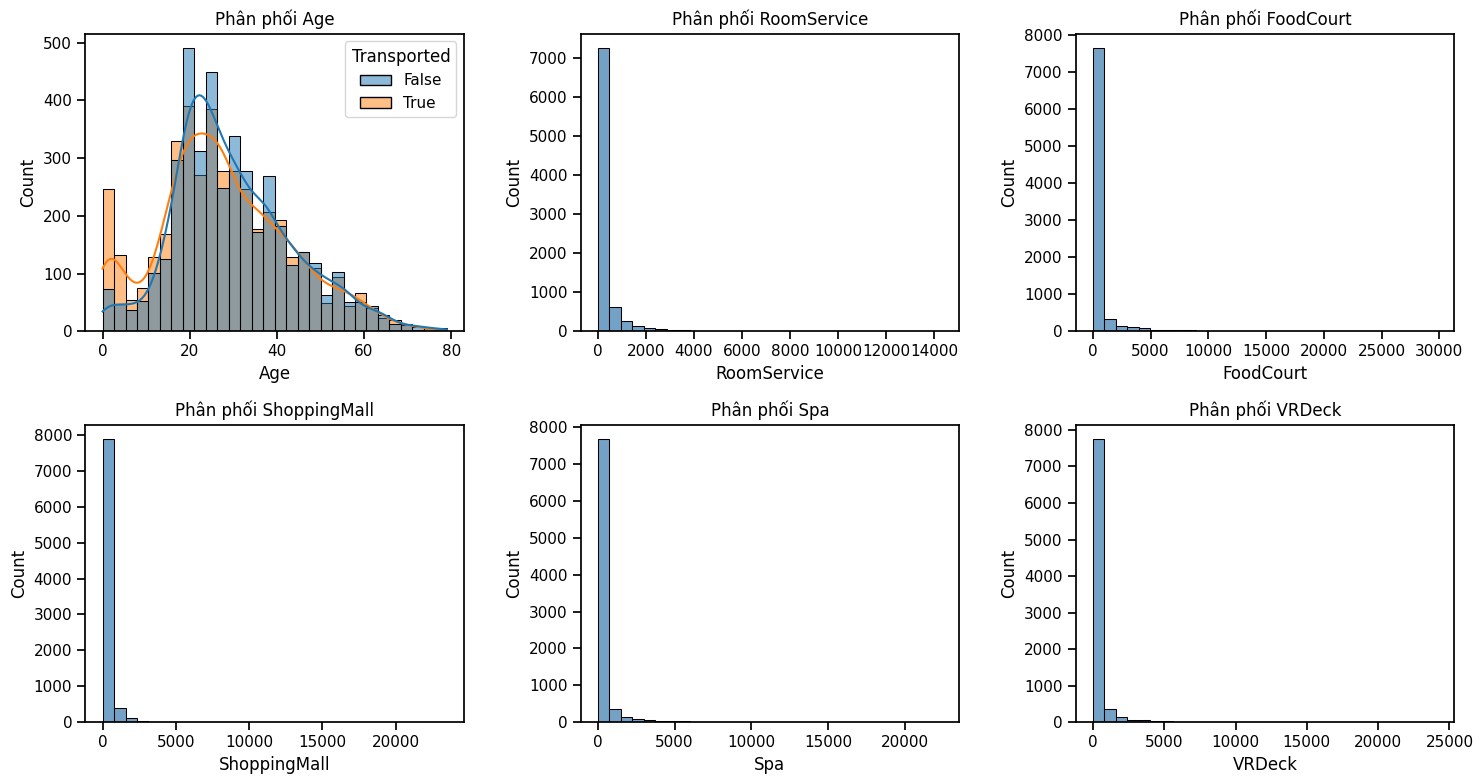

In [6]:
SPENDING_COLS = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

sns.histplot(
    data=train_df,
    x="Age",
    hue="Transported",
    kde=True,
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Phân phối Age")

for ax, col in zip(axes[1:], SPENDING_COLS):
    sns.histplot(
        data=train_df,
        x=col,
        bins=30,
        ax=ax,
        color="steelblue"
    )
    ax.set_title(f"Phân phối {col}")

plt.tight_layout()
plt.show()

### Nhận xét EDA

`CryoSleep` có liên hệ rõ với `Transported`. Các khoản chi tiêu lệch phải: phần lớn hành khách chi tiêu thấp hoặc bằng 0, nhưng vẫn có một số giá trị rất cao.

Do đó, em tạo thêm `TotalSpend`, `NoSpend`, `AmenitiesUsed` và các biến log chi tiêu. Những biến này giúp mô hình sử dụng cả mức chi tiêu tổng quát lẫn từng nhóm dịch vụ.

## 4. Feature engineering

In [7]:
SPENDING_COLS = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

# Chỉ dùng covariates của train và test, không sử dụng target.
all_passengers = pd.concat(
    [
        train_df.drop(columns=["Transported"]),
        test_df
    ],
    ignore_index=True
)

all_group_ids = (
    all_passengers["PassengerId"]
    .astype(str)
    .str.split("_")
    .str[0]
)

group_size_map = all_group_ids.value_counts()

all_temp = all_passengers.copy()
all_temp["GroupId"] = all_group_ids
all_temp["TotalSpend"] = (
    all_temp[SPENDING_COLS]
    .fillna(0)
    .sum(axis=1)
)

group_age_median_map = all_temp.groupby("GroupId")["Age"].median()
group_spend_mean_map = all_temp.groupby("GroupId")["TotalSpend"].mean()


def create_features(df):
    result = df.copy()

    passenger_parts = (
        result["PassengerId"]
        .astype(str)
        .str.split("_", expand=True)
    )

    result["GroupId"] = passenger_parts[0]
    result["MemberId"] = pd.to_numeric(
        passenger_parts[1],
        errors="coerce"
    )

    result["GroupSize"] = result["GroupId"].map(group_size_map)
    result["IsAlone"] = (result["GroupSize"] == 1).astype(int)
    result["GroupAgeMedian"] = result["GroupId"].map(group_age_median_map)
    result["GroupSpendMean"] = result["GroupId"].map(group_spend_mean_map)

    cabin_parts = result["Cabin"].str.split("/", expand=True)

    result["CabinDeck"] = cabin_parts[0]
    result["CabinNum"] = pd.to_numeric(
        cabin_parts[1],
        errors="coerce"
    )
    result["CabinSide"] = cabin_parts[2]

    # CabinNum theo vùng để giúp mô hình học vị trí cabin thô.
    result["CabinNumGroup"] = pd.cut(
        result["CabinNum"],
        bins=[-np.inf, 300, 600, 900, 1200, 1500, np.inf],
        labels=["A", "B", "C", "D", "E", "F"]
    )

    # Họ của hành khách dùng như đặc trưng phân loại.
    result["Surname"] = (
        result["Name"]
        .astype("string")
        .str.split()
        .str[-1]
    )

    result["TotalSpend"] = (
        result[SPENDING_COLS]
        .fillna(0)
        .sum(axis=1)
    )

    result["NoSpend"] = (
        result["TotalSpend"] == 0
    ).astype(int)

    result["AmenitiesUsed"] = (
        result[SPENDING_COLS]
        .fillna(0)
        .gt(0)
        .sum(axis=1)
    )

    for col in SPENDING_COLS + ["TotalSpend", "GroupSpendMean"]:
        result[f"Log_{col}"] = np.log1p(
            result[col].fillna(0)
        )

    result["AgeGroup"] = pd.cut(
        result["Age"],
        bins=[-np.inf, 12, 18, 25, 40, 60, np.inf],
        labels=[
            "Child",
            "Teen",
            "YoungAdult",
            "Adult",
            "MiddleAge",
            "Senior"
        ]
    )

    result["Cryo_NoSpend"] = (
        result["CryoSleep"].fillna(False).astype(int)
        * result["NoSpend"]
    )

    result["VIP_TotalSpend"] = (
        result["VIP"].fillna(False).astype(int)
        * result["TotalSpend"]
    )

    # Không đưa ID và chuỗi thô có độ phân giải quá cao vào mô hình.
    result = result.drop(
        columns=[
            "PassengerId",
            "Name",
            "Cabin",
            "GroupId"
        ],
        errors="ignore"
    )

    return result

In [8]:
X = create_features(
    train_df.drop(columns=["Transported"])
)

y = train_df["Transported"].astype(int)

X_kaggle_test = create_features(test_df)

test_passenger_ids = test_df["PassengerId"].copy()


def normalize_categorical_columns(dataframe):
    """Đưa mọi cột phân loại về cùng kiểu string.

    OneHotEncoder không chấp nhận một cột chứa lẫn bool và str.
    Hàm này đổi True/False, category và object thành chuỗi,
    đồng thời thay missing bằng nhãn 'Missing'.
    """
    result = dataframe.copy()

    categorical_like_cols = result.select_dtypes(
        include=["object", "category", "bool", "string"]
    ).columns.tolist()

    for col in categorical_like_cols:
        result[col] = (
            result[col]
            .astype("string")
            .fillna("Missing")
            .astype(str)
        )

    return result


X = normalize_categorical_columns(X)
X_kaggle_test = normalize_categorical_columns(X_kaggle_test)

print("X shape:", X.shape)
print("Test features shape:", X_kaggle_test.shape)

print("\nKiểu dữ liệu của các cột phân loại:")
display(X.select_dtypes(include=["object"]).dtypes)

display(X.head())

X shape: (8693, 33)
Test features shape: (4277, 33)

Kiểu dữ liệu của các cột phân loại:


HomePlanet       object
CryoSleep        object
Destination      object
VIP              object
CabinDeck        object
CabinSide        object
CabinNumGroup    object
Surname          object
AgeGroup         object
dtype: object

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,MemberId,GroupSize,IsAlone,GroupAgeMedian,GroupSpendMean,CabinDeck,CabinNum,CabinSide,CabinNumGroup,Surname,TotalSpend,NoSpend,AmenitiesUsed,Log_RoomService,Log_FoodCourt,Log_ShoppingMall,Log_Spa,Log_VRDeck,Log_TotalSpend,Log_GroupSpendMean,AgeGroup,Cryo_NoSpend,VIP_TotalSpend
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,1,1,1,39.0,0.0,B,0.0,P,A,Ofracculy,0.0,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Adult,0,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,1,1,1,24.0,736.0,F,0.0,S,A,Vines,736.0,0,5,4.700480,2.302585,3.258097,6.309918,3.806662,6.602588,6.602588,YoungAdult,0,0.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,1,2,0,45.5,7779.5,A,0.0,S,A,Susent,10383.0,0,4,3.784190,8.182280,0.000000,8.812248,3.912023,9.248021,8.959376,MiddleAge,0,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,2,2,0,45.5,7779.5,A,0.0,S,A,Susent,5176.0,0,4,0.000000,7.157735,5.918894,8.110728,5.267858,8.551981,8.959376,Adult,0,0.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,1,1,1,16.0,1091.0,F,1.0,S,A,Santantines,1091.0,0,5,5.717028,4.262680,5.023881,6.338594,1.098612,6.995766,6.995766,Teen,0,0.0


## 5. Chia train và validation

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)

print("\nTarget rate train:", round(y_train.mean(), 4))
print("Target rate validation:", round(y_valid.mean(), 4))

Train: (6954, 33) (6954,)
Validation: (1739, 33) (1739,)

Target rate train: 0.5036
Target rate validation: 0.5037


## 6. Pipeline tiền xử lý

In [10]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Số numeric columns:", len(numeric_cols))
print("Số categorical columns:", len(categorical_cols))

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Số numeric columns: 24
Số categorical columns: 9

Numeric columns:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'MemberId', 'GroupSize', 'IsAlone', 'GroupAgeMedian', 'GroupSpendMean', 'CabinNum', 'TotalSpend', 'NoSpend', 'AmenitiesUsed', 'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck', 'Log_TotalSpend', 'Log_GroupSpendMean', 'Cryo_NoSpend', 'VIP_TotalSpend']

Categorical columns:
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide', 'CabinNumGroup', 'Surname', 'AgeGroup']


In [11]:
try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=2,
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=2,
        sparse=False
    )

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Các cột phân loại đã được chuẩn hóa thành string và đã có nhãn "Missing".
# Vẫn giữ imputer để pipeline an toàn khi gặp np.nan ngoài dự kiến.
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        onehot
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_cols
    )
])

X_train_t = preprocessor.fit_transform(X_train)
X_valid_t = preprocessor.transform(X_valid)

print("X_train_t shape:", X_train_t.shape)
print("X_valid_t shape:", X_valid_t.shape)
print("Preprocessing chạy thành công.")

X_train_t shape: (6954, 1692)
X_valid_t shape: (1739, 1692)
Preprocessing chạy thành công.


## 7. Khởi tạo và đánh giá các mô hình

In [12]:
def evaluate_model(
    model_name,
    model,
    X_train,
    y_train,
    X_valid,
    y_valid
):
    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)
    probability = model.predict_proba(X_valid)[:, 1]

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            predictions,
            zero_division=0
        )
    }

    return result, predictions, probability

In [13]:
base_tree = DecisionTreeClassifier(
    max_depth=9,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)

try:
    bagging_model = BaggingClassifier(
        estimator=base_tree,
        n_estimators=300,
        max_samples=0.9,
        max_features=0.95,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
except TypeError:
    bagging_model = BaggingClassifier(
        base_estimator=base_tree,
        n_estimators=300,
        max_samples=0.9,
        max_features=0.95,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=13,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

extra_trees_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.035,
    max_depth=3,
    min_samples_leaf=4,
    subsample=0.9,
    random_state=RANDOM_STATE
)

stacking_estimators = [
    (
        "rf",
        RandomForestClassifier(
            n_estimators=350,
            max_depth=13,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    (
        "extra",
        ExtraTreesClassifier(
            n_estimators=350,
            max_depth=15,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            min_samples_leaf=4,
            subsample=0.9,
            random_state=RANDOM_STATE
        )
    )
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=2500
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

models = {
    "Bagging": bagging_model,
    "Random Forest": random_forest_model,
    "Extra Trees": extra_trees_model,
    "Gradient Boosting": gradient_boosting_model,
    "Stacking": stacking_model
}

print("Đã khởi tạo 5 mô hình Ensemble.")

Đã khởi tạo 5 mô hình Ensemble.


In [14]:
benchmark_rows = []
validation_predictions = {}
validation_probabilities = {}
fitted_models = {}

for model_name, model in models.items():
    result, predictions, probability = evaluate_model(
        model_name,
        model,
        X_train_t,
        y_train,
        X_valid_t,
        y_valid
    )

    benchmark_rows.append(result)
    validation_predictions[model_name] = predictions
    validation_probabilities[model_name] = probability
    fitted_models[model_name] = model

benchmark_df = pd.DataFrame(
    benchmark_rows
).sort_values(
    "Accuracy",
    ascending=False
)

display(benchmark_df)

,Model,Accuracy,Precision,Recall,F1
0,Bagging,0.805635,0.811343,0.800228,0.805747
4,Stacking,0.803335,0.799327,0.813927,0.806561
3,Gradient Boosting,0.800460,0.796857,0.810502,0.803622
1,Random Forest,0.746406,0.799175,0.663242,0.724891
2,Extra Trees,0.735480,0.795455,0.639269,0.708861


### Nhận xét benchmark

Bagging, Random Forest và Extra Trees giảm phương sai bằng cách kết hợp nhiều cây. Gradient Boosting xây dựng các cây theo tuần tự. Stacking dùng kết quả của nhiều mô hình cơ sở để huấn luyện một mô hình tổng hợp.

Ngoài Accuracy, em theo dõi Precision, Recall và F1-score để kiểm tra sự cân bằng giữa hai lớp. Vì các mô hình thường có kết quả rất gần nhau, em tiếp tục thử probability blending thay vì chỉ chọn cứng một mô hình.

## 8. Probability blending và điều chỉnh theo nhóm hành khách

Thông tin target của validation hoặc test không được dùng. Thống kê nhóm cho validation chỉ được tính từ `y_train`; thống kê nhóm cho test chỉ được tính từ toàn bộ nhãn train.

In [15]:
train_group_ids = (
    train_df.loc[X_train.index, "PassengerId"]
    .astype(str)
    .str.split("_")
    .str[0]
)

valid_group_ids = (
    train_df.loc[X_valid.index, "PassengerId"]
    .astype(str)
    .str.split("_")
    .str[0]
)

group_stats_valid = pd.DataFrame({
    "GroupId": train_group_ids.to_numpy(),
    "target": y_train.to_numpy()
}).groupby("GroupId")["target"].agg(["mean", "count"])

display(group_stats_valid.head())

,mean,count
GroupId,,
0001,0.0,1
0002,1.0,1
0003,0.0,2
0004,1.0,1
0006,1.0,2


In [16]:
def blend_with_group_information(
    base_probability,
    query_group_ids,
    group_stats,
    group_weight=0.5
):
    group_mean = (
        query_group_ids
        .map(group_stats["mean"])
        .to_numpy(dtype=float)
    )

    group_count = (
        query_group_ids
        .map(group_stats["count"])
        .fillna(0)
        .to_numpy(dtype=int)
    )

    adjusted_probability = base_probability.copy()

    # Chỉ dùng nhóm đã xuất hiện trong train và có nhãn thống nhất.
    usable_mask = (
        (group_count >= 1)
        & ~np.isnan(group_mean)
        & ((group_mean == 0.0) | (group_mean == 1.0))
    )

    adjusted_probability[usable_mask] = (
        (1 - group_weight)
        * base_probability[usable_mask]
        +
        group_weight
        * group_mean[usable_mask]
    )

    return adjusted_probability, usable_mask

In [17]:
blend_candidates = {
    "Bagging_only": {
        "Bagging": 1.0
    },
    "Stacking_only": {
        "Stacking": 1.0
    },
    "GB_only": {
        "Gradient Boosting": 1.0
    },
    "Bag_GB_Stack": {
        "Bagging": 0.34,
        "Gradient Boosting": 0.33,
        "Stacking": 0.33
    },
    "RF_Extra_GB_Stack": {
        "Random Forest": 0.20,
        "Extra Trees": 0.20,
        "Gradient Boosting": 0.30,
        "Stacking": 0.30
    },
    "All_models": {
        "Bagging": 0.20,
        "Random Forest": 0.15,
        "Extra Trees": 0.15,
        "Gradient Boosting": 0.25,
        "Stacking": 0.25
    }
}


def weighted_probability(probability_dict, weight_dict):
    total = np.zeros_like(
        next(iter(probability_dict.values())),
        dtype=float
    )

    weight_sum = 0.0

    for model_name, weight in weight_dict.items():
        total += weight * probability_dict[model_name]
        weight_sum += weight

    return total / weight_sum

In [18]:
search_rows = []
best_config = None
best_accuracy = -1.0

for blend_name, weights in blend_candidates.items():
    base_probability = weighted_probability(
        validation_probabilities,
        weights
    )

    for group_weight in [0.0, 0.25, 0.50, 0.75]:
        adjusted_probability, used_mask = (
            blend_with_group_information(
                base_probability,
                valid_group_ids,
                group_stats_valid,
                group_weight=group_weight
            )
        )

        for threshold in np.arange(0.44, 0.561, 0.01):
            predictions = (
                adjusted_probability >= threshold
            ).astype(int)

            accuracy = accuracy_score(
                y_valid,
                predictions
            )

            f1 = f1_score(
                y_valid,
                predictions,
                zero_division=0
            )

            row = {
                "blend": blend_name,
                "group_weight": group_weight,
                "threshold": round(float(threshold), 2),
                "accuracy": accuracy,
                "f1": f1,
                "group_adjusted_samples": int(used_mask.sum())
            }

            search_rows.append(row)

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_config = row.copy()

blend_search_df = pd.DataFrame(search_rows)

display(
    blend_search_df
    .sort_values(
        ["accuracy", "f1"],
        ascending=False
    )
    .head(20)
)

print("Cấu hình validation tốt nhất:")
print(best_config)

,blend,group_weight,threshold,accuracy,f1,group_adjusted_samples
65,Stacking_only,0.25,0.44,0.811961,0.822956,483
66,Stacking_only,0.25,0.45,0.811386,0.820765,483
52,Stacking_only,0.00,0.44,0.809661,0.820790,483
105,GB_only,0.00,0.45,0.809661,0.820402,483
118,GB_only,0.25,0.45,0.809661,0.820206,483
273,All_models,0.25,0.44,0.809661,0.819815,483
53,Stacking_only,0.00,0.45,0.809661,0.819422,483
10,Bagging_only,0.00,0.54,0.809661,0.802859,483
12,Bagging_only,0.00,0.56,0.809661,0.797801,483
67,Stacking_only,0.25,0.46,0.809086,0.817582,483


Cấu hình validation tốt nhất:
{'blend': 'Stacking_only', 'group_weight': 0.25, 'threshold': 0.44, 'accuracy': 0.81196089706728, 'f1': 0.8229561451001625, 'group_adjusted_samples': 483}


### Lựa chọn cấu hình cuối

Notebook chọn tổ hợp mô hình, trọng số nhóm và threshold có Accuracy validation cao nhất. Group-aware blending chỉ dùng target của các thành viên thuộc tập train, không dùng nhãn validation hay test.

Tuy nhiên, việc tối ưu threshold trên một validation split vẫn có thể overfit nhẹ. Vì vậy notebook xuất thêm nhiều submission hợp lệ để có thể so sánh trên Kaggle thay vì phụ thuộc tuyệt đối vào một cấu hình.

Blend: Stacking_only
Weights: {'Stacking': 1.0}
Group weight: 0.25
Threshold: 0.44

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       863
           1       0.78      0.87      0.82       876

    accuracy                           0.81      1739
   macro avg       0.82      0.81      0.81      1739
weighted avg       0.82      0.81      0.81      1739



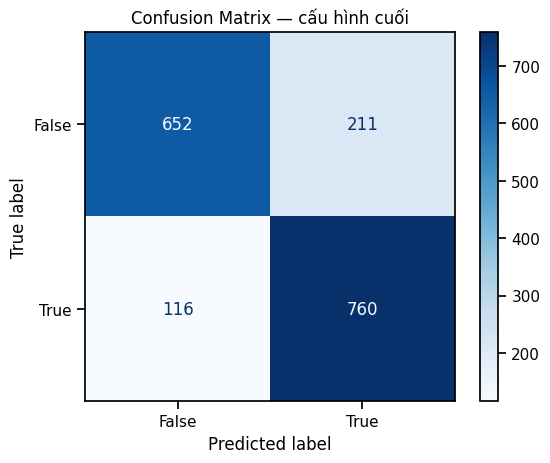

In [19]:
selected_blend_name = best_config["blend"]
selected_weights = blend_candidates[selected_blend_name]
selected_group_weight = best_config["group_weight"]
selected_threshold = best_config["threshold"]

selected_valid_base_probability = weighted_probability(
    validation_probabilities,
    selected_weights
)

selected_valid_probability, selected_used_mask = (
    blend_with_group_information(
        selected_valid_base_probability,
        valid_group_ids,
        group_stats_valid,
        group_weight=selected_group_weight
    )
)

selected_valid_predictions = (
    selected_valid_probability >= selected_threshold
).astype(int)

print("Blend:", selected_blend_name)
print("Weights:", selected_weights)
print("Group weight:", selected_group_weight)
print("Threshold:", selected_threshold)

print("\nClassification report:")
print(
    classification_report(
        y_valid,
        selected_valid_predictions,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_valid,
    selected_valid_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[False, True]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — cấu hình cuối")
plt.grid(False)
plt.show()

## 9. Huấn luyện lại trên toàn bộ train và tạo submission

In [20]:
final_preprocessor = clone(preprocessor)

X_full_t = final_preprocessor.fit_transform(X)
X_kaggle_test_t = final_preprocessor.transform(X_kaggle_test)

final_models = {}

for model_name, model_template in models.items():
    model = clone(model_template)
    model.fit(X_full_t, y)
    final_models[model_name] = model



In [21]:
test_probabilities = {
    model_name: model.predict_proba(X_kaggle_test_t)[:, 1]
    for model_name, model in final_models.items()
}

test_blend_probability = weighted_probability(
    test_probabilities,
    selected_weights
)

full_train_group_ids = (
    train_df["PassengerId"]
    .astype(str)
    .str.split("_")
    .str[0]
)

test_group_ids = (
    test_df["PassengerId"]
    .astype(str)
    .str.split("_")
    .str[0]
)

group_stats_full = pd.DataFrame({
    "GroupId": full_train_group_ids,
    "target": y.to_numpy()
}).groupby("GroupId")["target"].agg(["mean", "count"])

test_adjusted_probability, test_group_mask = (
    blend_with_group_information(
        test_blend_probability,
        test_group_ids,
        group_stats_full,
        group_weight=selected_group_weight
    )
)

test_predictions_final = (
    test_adjusted_probability >= selected_threshold
)

print("Số hành khách test được điều chỉnh theo nhóm:", test_group_mask.sum())
print("Tỷ lệ dự đoán Transported:", round(test_predictions_final.mean(), 4))

Số hành khách test được điều chỉnh theo nhóm: 0
Tỷ lệ dự đoán Transported: 0.5684


In [22]:
OUTPUT_DIR = Path("submissions")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_submission(filename, predictions):
    submission = pd.DataFrame({
        "PassengerId": test_passenger_ids,
        "Transported": np.asarray(predictions).astype(bool)
    })

    path = OUTPUT_DIR / filename
    submission.to_csv(path, index=False)

    assert submission.shape[0] == test_df.shape[0]
    assert submission["PassengerId"].equals(test_df["PassengerId"])
    assert submission["Transported"].dtype == bool
    assert submission.isna().sum().sum() == 0

    print(
        filename,
        "| rows =", len(submission),
        "| transported_rate =", round(submission["Transported"].mean(), 4)
    )

    return submission, path


# File chính: cấu hình blend + group adjustment tốt nhất trên validation.
submission_main, main_path = save_submission(
    "submission_hw11.csv",
    test_predictions_final
)

# Các file dự phòng để thử trên Kaggle.
best_single_name = benchmark_df.iloc[0]["Model"]
best_single_predictions = (
    test_probabilities[best_single_name] >= 0.5
)

submission_single, single_path = save_submission(
    "submission_best_single.csv",
    best_single_predictions
)

plain_blend_predictions = (
    test_blend_probability >= selected_threshold
)

submission_plain_blend, plain_blend_path = save_submission(
    "submission_plain_blend.csv",
    plain_blend_predictions
)

stacking_predictions = (
    test_probabilities["Stacking"] >= 0.5
)

submission_stacking, stacking_path = save_submission(
    "submission_stacking.csv",
    stacking_predictions
)

gradient_predictions = (
    test_probabilities["Gradient Boosting"] >= 0.5
)

submission_gradient, gradient_path = save_submission(
    "submission_gradient_boosting.csv",
    gradient_predictions
)



display(submission_main.head())

submission_hw11.csv | rows = 4277 | transported_rate = 0.5684
submission_best_single.csv | rows = 4277 | transported_rate = 0.5071
submission_plain_blend.csv | rows = 4277 | transported_rate = 0.5684
submission_stacking.csv | rows = 4277 | transported_rate = 0.5343
submission_gradient_boosting.csv | rows = 4277 | transported_rate = 0.5343


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


# Kết quả Kaggle

- Cấu hình validation tốt nhất: **Stacking, threshold 0.44**
- Validation Accuracy: **0.8120**
- Validation F1-score: **0.8230**
- File Kaggle tốt nhất: **submission_hw11.csv**
- Kaggle public leaderboard score: **0.80009**

## Kết luận

Em đã so sánh Bagging, Random Forest, Extra Trees, Gradient Boosting và Stacking. Kết quả validation tốt nhất đạt Accuracy khoảng 0.8120 và F1-score khoảng 0.8230 với Stacking và threshold 0.44.

Em cũng thử điều chỉnh dự đoán dựa trên thông tin các thành viên cùng nhóm. Tuy nhiên, không có GroupId nào trong tập test trùng với tập train, nên phần điều chỉnh theo nhóm không tác động đến submission cuối. Vì vậy, file chính thực tế sử dụng xác suất của Stacking với threshold 0.44.

Sau khi nộp nhiều cấu hình hợp lệ lên Kaggle, em chọn file có public leaderboard score cao nhất làm kết quả cuối cùng.